# EDA — Petróleo

---
## 0. Configuración del Dataset

In [30]:
# ============================================================
# CONFIGURACIÓN: PETRÓLEO
# ============================================================

DATASET_CONFIG = {
    'nombre': 'petróleo',
    'archivo': 'petroleo_precio_diario_barril_1946_2026.csv',
'frecuencia_original': 'diaria',
    'col_fecha': 'fecha',
    'variable_principal': 'usd_barril',
    'variables_desgloses': [],
    'columnas_numericas': [
        'usd_barril',
    ],
    'unidades': 'USD por barril',
    'notas': 'EIA. Serie unificada WTI+Brent (USD/barril). WTI desde 1946, Brent desde 1987. Cierre de mercado.',
}

VAR_PRINCIPAL = DATASET_CONFIG['variable_principal']
NOMBRE        = DATASET_CONFIG['nombre']
UNIDADES      = DATASET_CONFIG['unidades']

PERIODO_ESTACIONAL = {
    'trimestral': 4,
    'mensual': 12,
    'diaria': 365,
}[DATASET_CONFIG['frecuencia_original']]

LAGS_ACF = {
    'trimestral': 16,
    'mensual': 36,
    'diaria': 60,
}[DATASET_CONFIG['frecuencia_original']]

print(f'Dataset configurado: {NOMBRE}')
print(f'Variable principal:  {VAR_PRINCIPAL}')
print(f'Frecuencia:          {DATASET_CONFIG["frecuencia_original"]}')
print(f'Periodo estacional:  {PERIODO_ESTACIONAL}')

Dataset configurado: petróleo
Variable principal:  usd_barril
Frecuencia:          diaria
Periodo estacional:  365


---
## Imports

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import warnings
from pathlib import Path
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

RUTA_BASE = Path(r'C:\Users\marco\PycharmProjects\TFM_Marcos\Datasets')

COLOR_PRINCIPAL = '#5E35B1'
COLORES_DESGLOSES = ['#00897B', '#FF7043', '#FFC107', '#1565C0', '#AD1457']

EVENTOS = {
    '1973-10-01': 'OPEC I',
    '1979-01-01': 'OPEC II',
    '1990-08-01': 'Iraq',
    '1998-12-01': 'Mín 98',
    '2008-07-01': 'Máx 08',
    '2014-06-01': 'Shale\ncollapse',
    '2020-04-20': 'WTI\nnegativo',
    '2022-02-24': 'Ucrania',
}

---
## 1. Carga y Diagnóstico Básico

In [32]:
ruta = RUTA_BASE / DATASET_CONFIG['archivo']
df = pd.read_csv(ruta)
df[DATASET_CONFIG['col_fecha']] = pd.to_datetime(df[DATASET_CONFIG['col_fecha']])
df = df.set_index(DATASET_CONFIG['col_fecha']).sort_index()

for col in DATASET_CONFIG['columnas_numericas']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset: {NOMBRE}')
print(f'Notas:   {DATASET_CONFIG["notas"]}')
print('=' * 60)
print(f'Shape:          {df.shape}')
print(f'Rango temporal: {df.index.min().date()} a {df.index.max().date()}')
print(f'Observaciones:  {len(df)}')
print(f'Columnas:       {list(df.columns)}')

Dataset: petróleo
Notas:   EIA. Serie unificada WTI+Brent (USD/barril). WTI desde 1946, Brent desde 1987. Cierre de mercado.
Shape:          (18721, 6)
Rango temporal: 1974-07-01 a 2025-10-01
Observaciones:  18721
Columnas:       ['año', 'trimestre', 'mes', 'wti_usd_barril', 'brent_usd_barril', 'usd_barril']


In [33]:
print('Primeras 3 filas:')
display(df.head(3))
print('\nÚltimas 3 filas:')
display(df.tail(3))

Primeras 3 filas:


,año,trimestre,mes,wti_usd_barril,brent_usd_barril,usd_barril
fecha,,,,,,
1974-07-01,1974,3,7,10.110,NaN,10.110
1974-07-02,1974,3,7,10.110,NaN,10.110
1974-07-03,1974,3,7,10.110,NaN,10.110



Últimas 3 filas:


,año,trimestre,mes,wti_usd_barril,brent_usd_barril,usd_barril
fecha,,,,,,
2025-09-29,2025,3,9,62.527,69.000,69.000
2025-09-30,2025,3,9,62.425,68.520,68.520
2025-10-01,2025,4,10,62.323,66.670,66.670


In [34]:
cols_num = DATASET_CONFIG['columnas_numericas']
cols_num = [c for c in cols_num if c in df.columns]

nulos = pd.DataFrame({
    'n_nulos': df[cols_num].isnull().sum(),
    'pct_nulos': df[cols_num].isnull().mean() * 100,
    'primer_valido': [df[c].first_valid_index() for c in cols_num],
    'ultimo_valido': [df[c].last_valid_index() for c in cols_num],
}).round(2)

print('Diagnóstico de valores faltantes:')
display(nulos)

n_dupl = df.index.duplicated().sum()
print(f'\nDuplicados de fecha: {n_dupl}')

Diagnóstico de valores faltantes:


,n_nulos,pct_nulos,primer_valido,ultimo_valido
usd_barril,0,0.000,1974-07-01,2025-10-01



Duplicados de fecha: 0


In [35]:
if len(df) > 1:
    diffs = df.index.to_series().diff().dropna()
    print(f'Intervalo mediano entre observaciones: {diffs.median()}')
    print(f'Intervalo mínimo:                      {diffs.min()}')
    print(f'Intervalo máximo:                      {diffs.max()}')

    umbral = diffs.median() * 2
    huecos = diffs[diffs > umbral]
    if len(huecos) > 0:
        print(f'\nHuecos temporales detectados ({len(huecos)}):')
        print(huecos)

Intervalo mediano entre observaciones: 1 days 00:00:00
Intervalo mínimo:                      1 days 00:00:00
Intervalo máximo:                      1 days 00:00:00


---
## 2. Series Temporales

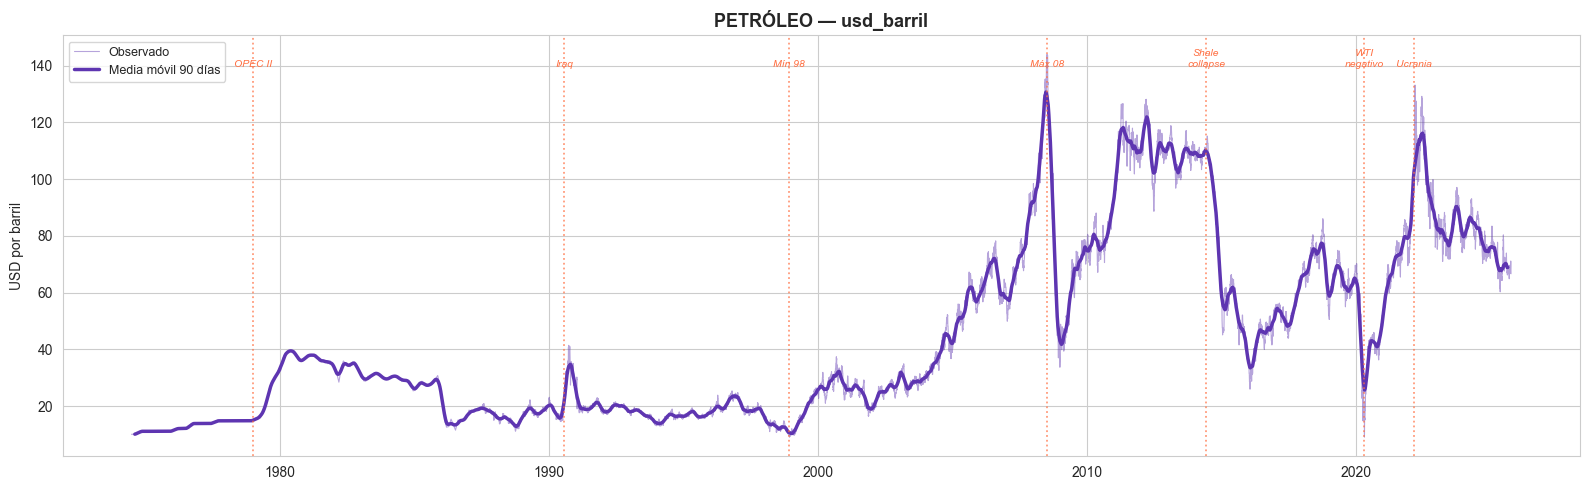

Mín: 9.10  (1998-12-10)
Máx: 143.95  (2008-07-03)


In [36]:
ventana_mm = 90

fig, ax = plt.subplots(figsize=(16, 5))

y = df[VAR_PRINCIPAL].dropna()
mm = y.rolling(ventana_mm, center=True).mean()

ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=0.8, alpha=0.45, label='Observado')
ax.plot(y.index, mm, color=COLOR_PRINCIPAL, lw=2.5,
        label=f'Media móvil 90 días')

y_max = y.max()
for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if y.index.min() <= fecha_ev <= y.index.max():
        ax.axvline(fecha_ev, color='#FF7043', linestyle=':', lw=1.3, alpha=0.7)
        ax.text(fecha_ev, y_max * 0.97, texto,
                ha='center', fontsize=7.5, color='#FF7043', fontstyle='italic')

ax.set_title(f'{NOMBRE.upper()} — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')
ax.set_ylabel(UNIDADES, fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mín: {y.min():.2f}  ({y.idxmin().date()})')
print(f'Máx: {y.max():.2f}  ({y.idxmax().date()})')

### Análisis:

El `usd_barril` (precio del petróleo en dólares por barril, serie unificada WTI hasta 1987 y Brent después) describe una trayectoria sin tendencia monótona pero con oscilaciones de gran amplitud ancladas en shocks geopolíticos y de demanda identificables, recorriendo desde un mínimo de 9,10 dólares en diciembre de 1998 hasta un máximo histórico de 143,95 dólares en julio de 2008. A diferencia de los índices de precios, el petróleo no acumula crecimiento sostenido sino que revierte entre regímenes de precio bajo y alto separados por episodios abruptos.

Se distinguen varios tramos. El precio permanece en torno a 10 dólares hasta 1978 y se dispara con el segundo shock petrolífero de 1979-1980 (OPEP II, alrededor de 40 dólares), para desplomarse en el contrashock de 1986 hasta la banda de 15-20 dólares en la que oscila durante los años 90, con un repunte transitorio en la Guerra del Golfo de 1990 y el mínimo histórico de 9,10 dólares en 1998. A partir de 2002 inicia el mayor ciclo alcista de la muestra, impulsado por la demanda asiática, hasta el pico de 143,95 dólares en 2008, seguido del desplome de la crisis financiera (hasta unos 40 dólares en 2009) y una recuperación a la banda de 100-120 dólares entre 2011 y 2014. El colapso del shale de 2014-2016 lo devuelve a 30-50 dólares, y tras el desplome puntual de 2020 (con el WTI en negativo, recogido aquí como suelo en torno a 9 dólares) repunta con la invasión de Ucrania de 2022 hasta unos 120 dólares, cerrando la muestra en la banda de 65-90 dólares.

Para la predicción del paro, el petróleo opera por dos canales de signo opuesto: el de oferta (un encarecimiento del crudo eleva costes y puede deprimir la actividad y el empleo) y el de demanda (los precios altos coinciden con expansiones globales de demanda y, por tanto, con paro bajo). El análisis de la sección 9 determina cuál domina sobre la forma estacionaria.

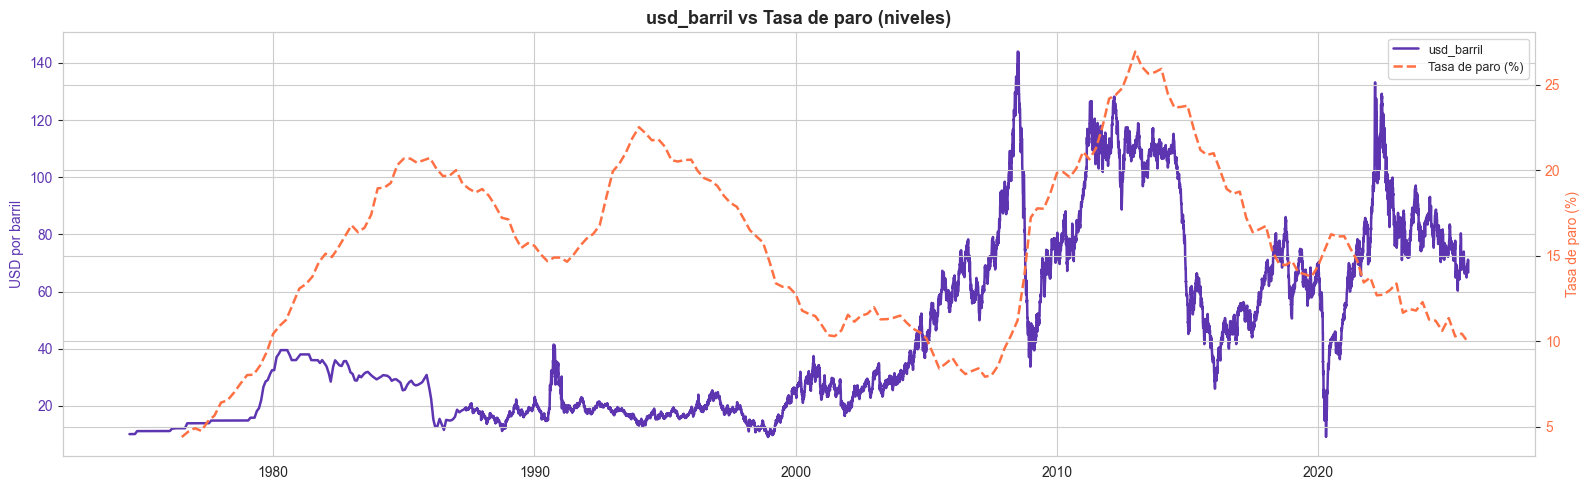

In [37]:
# Comparación de niveles con la tasa de paro (antes de analizar estacionariedad)
ruta_paro_s2 = RUTA_BASE / 'parados_sexo_edad.csv'
df_paro_s2 = pd.read_csv(ruta_paro_s2)
df_paro_s2['fecha'] = pd.to_datetime(df_paro_s2['fecha'])
df_paro_s2 = df_paro_s2.set_index('fecha').sort_index()
tasa_paro_s2 = pd.to_numeric(df_paro_s2['tasa_paro_ambos_sexos_total'], errors='coerce').dropna()

y = df[VAR_PRINCIPAL].dropna()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
ax1.plot(y.index, y, color=COLOR_PRINCIPAL, lw=1.8, label=VAR_PRINCIPAL)
ax2.plot(tasa_paro_s2.index, tasa_paro_s2, color='#FF7043', lw=1.8, linestyle='--', label='Tasa de paro (%)')
ax1.set_ylabel(UNIDADES, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')
ax1.set_title(f'{VAR_PRINCIPAL} vs Tasa de paro (niveles)', fontsize=13, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc='best')
plt.tight_layout()
plt.show()


### Análisis:

La relación en niveles entre el `usd_barril` y la tasa de paro no presenta un signo contemporáneo estable, en coherencia con la naturaleza del petróleo como precio mean-reverting sin tendencia frente a un paro cíclico. Entre 1979 y 1985 ambos suben (el crudo en el segundo shock petrolífero hasta unos 35-40 dólares, el paro del 5% al 21%), un tramo en que el canal de oferta y la crisis de la Transición coinciden. Entre 1986 y 1999 el crudo permanece deprimido en la banda de 15-20 dólares mientras el paro se mantiene estructuralmente alto (15-24%), sin co-movimiento definido. Entre 2000 y 2008 el crudo se dispara desde unos 20 hasta 144 dólares mientras el paro desciende del 15% al 8%, una relación claramente inversa que refleja el ciclo de demanda global: el petróleo caro acompaña la expansión económica que reduce el desempleo. La Gran Recesión rompe ese paralelismo: el crudo cae y rebota con volatilidad mientras el paro escala al 27% en 2013. El signo cambiante por tramos anticipa una correlación condicionada al canal dominante; el análisis cuantitativo de la sección 9 se realiza sobre la variación interanual del precio, donde emerge una relación negativa moderada.

---
## 3. Distribución y Outliers

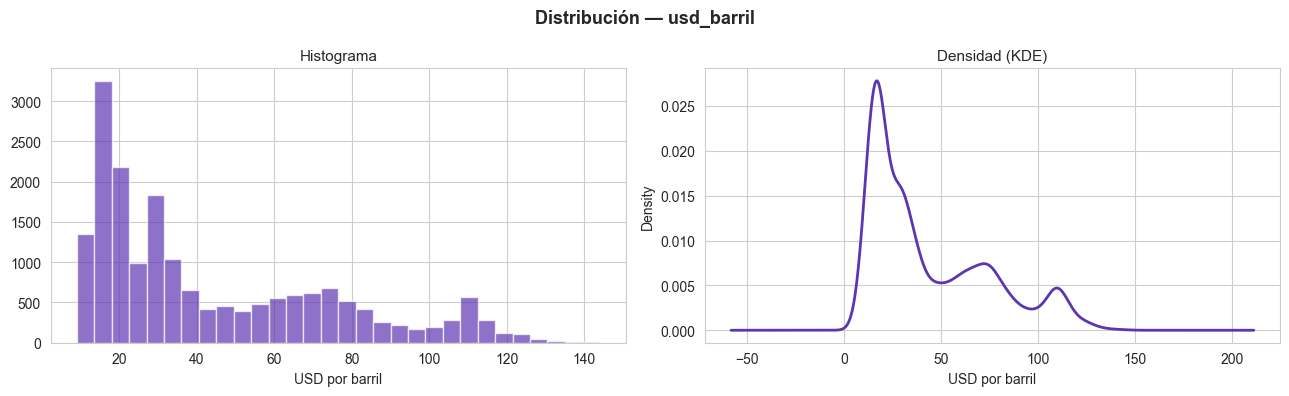

Asimetría (skewness): 0.946
Curtosis:             -0.224


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Distribución — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].hist(y, bins=30, color=COLOR_PRINCIPAL, alpha=0.7, edgecolor='white')
axes[0].set_xlabel(UNIDADES, fontsize=10)
axes[0].set_title('Histograma', fontsize=11)

y.plot.kde(ax=axes[1], color=COLOR_PRINCIPAL, lw=2)
axes[1].set_xlabel(UNIDADES, fontsize=10)
axes[1].set_title('Densidad (KDE)', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Asimetría (skewness): {y.skew():.3f}')
print(f'Curtosis:             {y.kurtosis():.3f}')

### Análisis:

La distribución del `usd_barril` es marcadamente asimétrica hacia la derecha, con la mayor parte de las observaciones concentradas en la banda de precios bajos (aproximadamente 10-40 dólares), correspondiente al largo periodo 1986-2004, y una cola derecha extendida hasta el máximo de 143,95 dólares que recoge los episodios de precios altos de 2008-2014 y 2022. La asimetría positiva de 0,946 cuantifica este sesgo: el cuerpo de la distribución se ancla en el régimen de precios bajos, históricamente más prolongado, mientras los precios elevados, más recientes y breves, forman la cola.

La curtosis ligeramente negativa de -0,224 indica una distribución algo más plana que la normal, con la masa repartida entre el régimen de precios bajos y el tramo intermedio-alto sin una concentración central pronunciada, reflejo de que el petróleo ha pasado tiempo significativo en niveles muy distintos a lo largo de la muestra. Esta forma no es un artefacto estadístico sino el reflejo directo de la estructura por regímenes de la serie, y confirma que el nivel del precio no es adecuado como variable directa sin transformación: la variación interanual, que se adopta como forma estacionaria, elimina la asimetría y la dependencia del régimen de precio.

In [39]:
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
limite_inf_iqr = Q1 - 1.5 * IQR
limite_sup_iqr = Q3 + 1.5 * IQR

z_scores = np.abs(stats.zscore(y.dropna()))
outliers_z = y[z_scores > 3]
outliers_iqr = y[(y < limite_inf_iqr) | (y > limite_sup_iqr)]

print(f'Outliers por IQR  (1.5×): {len(outliers_iqr)}')
print(f'Outliers por z-score (>3): {len(outliers_z)}')

extremos = pd.concat([
    y.nsmallest(5).rename('valor'),
    y.nlargest(5).rename('valor')
]).sort_values()

print('\n10 valores extremos (5 mínimos + 5 máximos):')
print(extremos.to_frame().reset_index().to_string(index=False))

Outliers por IQR  (1.5×): 14
Outliers por z-score (>3): 15

10 valores extremos (5 mínimos + 5 máximos):
     fecha   valor
1998-12-10   9.100
2020-04-21   9.120
1998-12-11   9.260
1998-12-12   9.260
1998-12-13   9.260
2008-07-11 143.680
2008-07-04 143.950
2008-07-03 143.950
2008-07-05 143.950
2008-07-06 143.950


### Análisis:

El `usd_barril` presenta 14 outliers por criterio IQR y 15 por z-score, un número reducido sobre 18.721 observaciones diarias que se concentra en los dos extremos del rango de precios. A diferencia de los índices, donde la tendencia dilataba el rango intercuartílico hasta absorber todos los valores, aquí los episodios de precio extremo sí quedan marcados, porque el cuerpo de la distribución se sitúa en precios bajos y los picos de 2008 sobresalen con claridad.

Los diez valores extremos delimitan los dos hitos históricos de la serie: los cinco mínimos corresponden al desplome de diciembre de 1998 (9,10 dólares, el mínimo absoluto) y al colapso del confinamiento de abril de 2020 (9,12 dólares, cuando el WTI llegó a cotizar en negativo y la serie unificada recoge este suelo), y los cinco máximos al pico del superciclo de demanda de julio de 2008 (143,95 dólares). Estos valores no son anomalías de medición sino los puntos de inflexión económicamente más relevantes de la serie, los momentos de máxima debilidad y máxima fortaleza del precio del crudo. Su tratamiento como valores genuinos, no como errores, es coherente con la naturaleza de la variable.

In [40]:
if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
    y_periodo = y.index.quarter.map({1:'T1', 2:'T2', 3:'T3', 4:'T4'})
    titulo_grupo = 'Trimestre'
    orden_periodos = ['T1', 'T2', 'T3', 'T4']
elif DATASET_CONFIG['frecuencia_original'] == 'mensual':
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses
else:
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses

colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
               '#1565C0', '#AD1457', '#2E7D32', '#E65100',
               '#6A1B9A', '#00695C', '#F57F17', '#37474F']

df_box = pd.DataFrame({
    'periodo': y_periodo.values,
    'valor': y.values,
    'fecha': y.index.strftime('%Y-%m-%d'),
})
df_box['periodo'] = pd.Categorical(df_box['periodo'],
                                    categories=[p for p in orden_periodos if p in df_box['periodo'].values],
                                    ordered=True)

fig = px.box(
    df_box, x='periodo', y='valor', color='periodo',
    hover_data=['fecha'],
    title=f'Distribución por {titulo_grupo} — {VAR_PRINCIPAL}',
    labels={'valor': UNIDADES, 'periodo': titulo_grupo, 'fecha': 'Fecha'},
    color_discrete_sequence=colores_bp,
    category_orders={'periodo': orden_periodos},
)
fig.update_layout(showlegend=False, height=420)
fig.show()

### Análisis:

La distribución por mes del `usd_barril` no presenta patrón estacional alguno. Las doce cajas son prácticamente idénticas en mediana (en torno a 30 dólares), rango intercuartílico (aproximadamente 18-65 dólares) y extensión de los bigotes (hasta unos 120-145 dólares), sin desplazamiento sistemático de ningún mes. El precio del petróleo responde a la oferta de la OPEP, los inventarios estratégicos, la demanda industrial global y la geopolítica, factores que no siguen un calendario mensual recurrente, por lo que la ausencia de estacionalidad es la esperada para un precio de materia prima cotizado en mercados internacionales. La amplitud de cada caja refleja el amplio recorrido de la serie a lo largo de las décadas, no variación intraanual. El resampleo trimestral por media no introduce ni elimina patrón estacional.

---
## 4. Estacionalidad

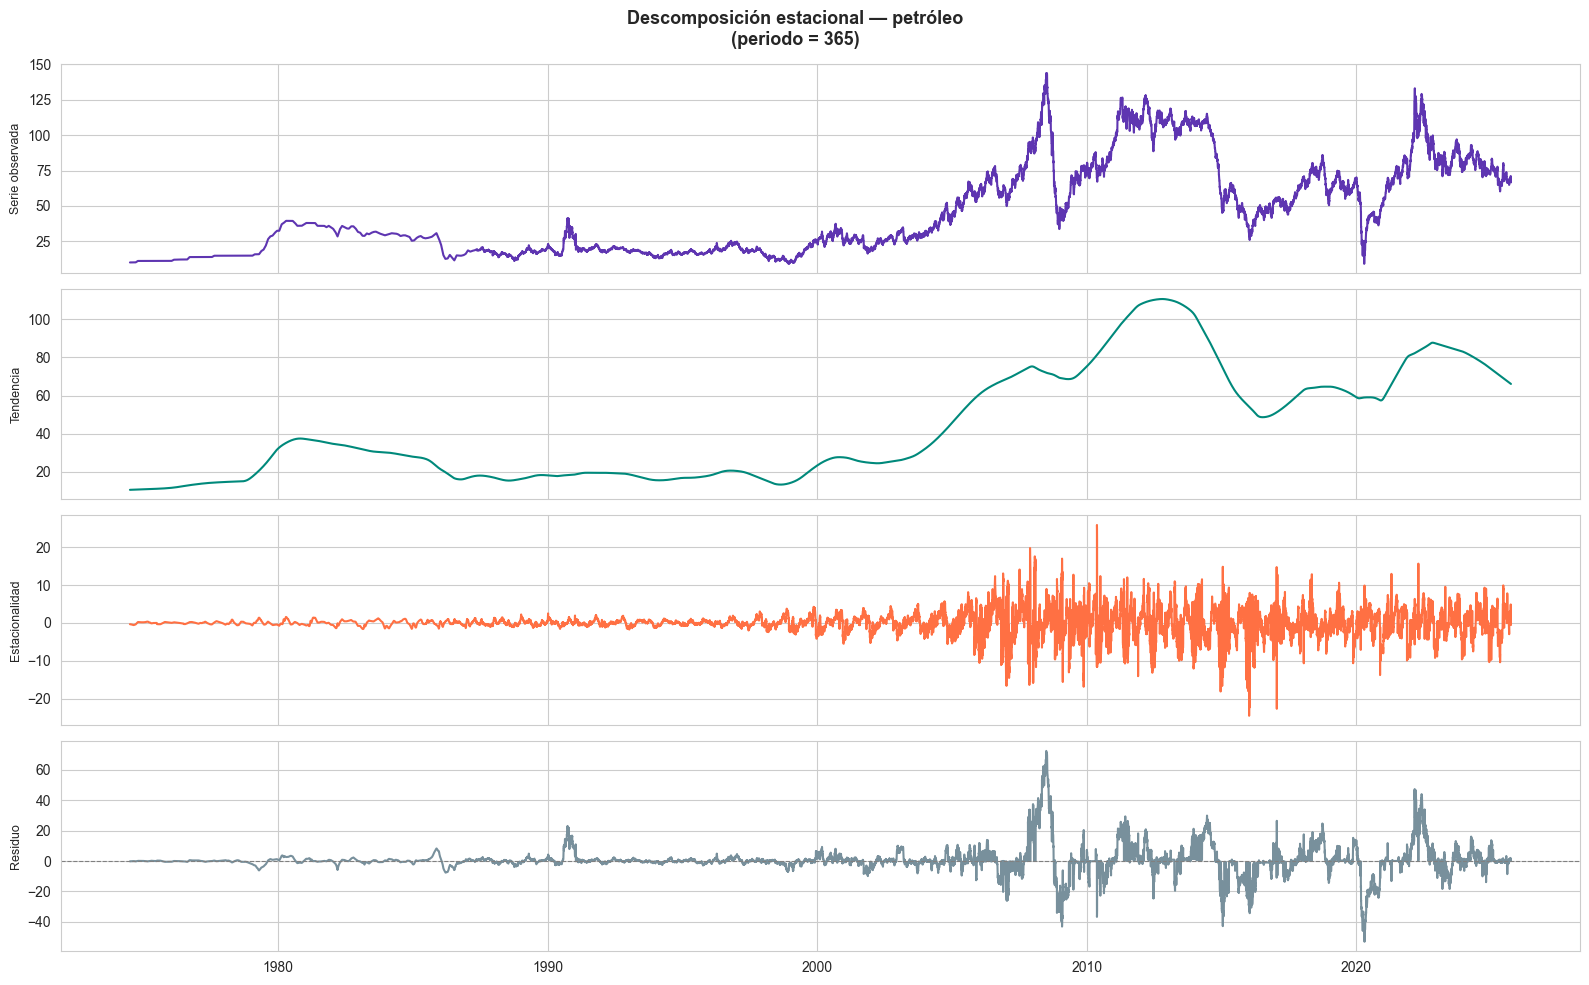

In [41]:
y_descomp = y.dropna()

if len(y_descomp) >= 2 * PERIODO_ESTACIONAL:
    stl = STL(y_descomp, period=365, robust=True)
    descomp = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Descomposición estacional — {NOMBRE}\n(periodo = {PERIODO_ESTACIONAL})',
                 fontsize=13, fontweight='bold')

    componentes = [
        ('Serie observada', descomp.observed, COLOR_PRINCIPAL),
        ('Tendencia', descomp.trend, '#00897B'),
        ('Estacionalidad', descomp.seasonal, '#FF7043'),
        ('Residuo', descomp.resid, '#78909C'),
    ]

    for ax, (titulo, datos, color) in zip(axes, componentes):
        ax.plot(datos.index, datos, color=color, lw=1.5)
        ax.set_ylabel(titulo, fontsize=9)
        if titulo == 'Residuo':
            ax.axhline(0, color='gray', linestyle='--', lw=0.8)

    plt.tight_layout()
    plt.show()
else:
    print(f'Serie demasiado corta para descomposición (necesita ≥ {2*PERIODO_ESTACIONAL} obs, tiene {len(y_descomp)})')

### Análisis:

La descomposición STL con periodo 365 confirma lo anticipado por el boxplot mensual: el componente estacional del `usd_barril` es negligible y carece de interpretación económica, como corresponde a un precio de materia prima cotizado en mercados internacionales sin calendario estacional doméstico.

La tendencia captura la práctica totalidad de la dinámica de medio plazo de la serie: la subida del segundo shock petrolífero, la larga meseta baja de los años 90, el superciclo alcista hasta 2008, y las oscilaciones posteriores entre el colapso del shale y los repuntes recientes. El componente más informativo es el residuo, que exhibe una heterocedasticidad muy marcada con clustering de volatilidad: los periodos tranquilos de los años 90, con precio estable en torno a 15-20 dólares, alternan con episodios de volatilidad extrema concentrada en los shocks (1979-1986, 2008-2009, 2014-2016 y 2020). Esta volatilidad condicional, característica de los mercados de materias primas y de tipo análogo a la del tipo de cambio, queda documentada como rasgo de la serie; no es proporcional al nivel ni admite corrección por logaritmo, y su tratamiento se difiere a las fases de feature engineering y modelización.

In [42]:
if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):

    if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
        grupo_idx = y.index.quarter
        etiq_idx = ['T1', 'T2', 'T3', 'T4']
    else:
        grupo_idx = y.index.month
        etiq_idx = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

    media_por_periodo = pd.Series(
        {p: y[grupo_idx == p].mean() for p in sorted(np.unique(grupo_idx))}
    )
    indice_estacional = (media_por_periodo / media_por_periodo.mean() * 100).round(1)
    indice_estacional.index = etiq_idx[:len(indice_estacional)]

    fig, ax = plt.subplots(figsize=(8, 4))
    colores_idx = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
                   '#1565C0', '#AD1457', '#2E7D32', '#E65100',
                   '#6A1B9A', '#00695C', '#F57F17', '#37474F']
    barras = ax.bar(indice_estacional.index, indice_estacional.values,
                    color=colores_idx[:len(indice_estacional)], edgecolor='white',
                    linewidth=1.5, alpha=0.85)
    ax.axhline(100, color='gray', linestyle='--', lw=1.2, label='Media = 100')
    ax.set_title(f'Índices estacionales — {NOMBRE}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Índice (100 = media global)', fontsize=10)
    for b, v in zip(barras, indice_estacional.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Índices estacionales:')
    print(indice_estacional.to_string())
    print(f'\nPeriodo con mayor {NOMBRE}: {indice_estacional.idxmax()} ({indice_estacional.max():.1f})')
    print(f'Periodo con menor {NOMBRE}: {indice_estacional.idxmin()} ({indice_estacional.min():.1f})')

### Análisis:

El cálculo de índices estacionales por mes o trimestre no se aplica a una serie de frecuencia diaria como el `usd_barril`: la estacionalidad de esta variable ya queda evaluada en el boxplot mensual y en la descomposición STL de periodo 365, ambos concluyentes en que el precio del petróleo carece de patrón estacional económicamente relevante. El resampleo trimestral por media, por tanto, no requiere corrección estacional previa.

---
## 5. Cambios Periodo a Periodo

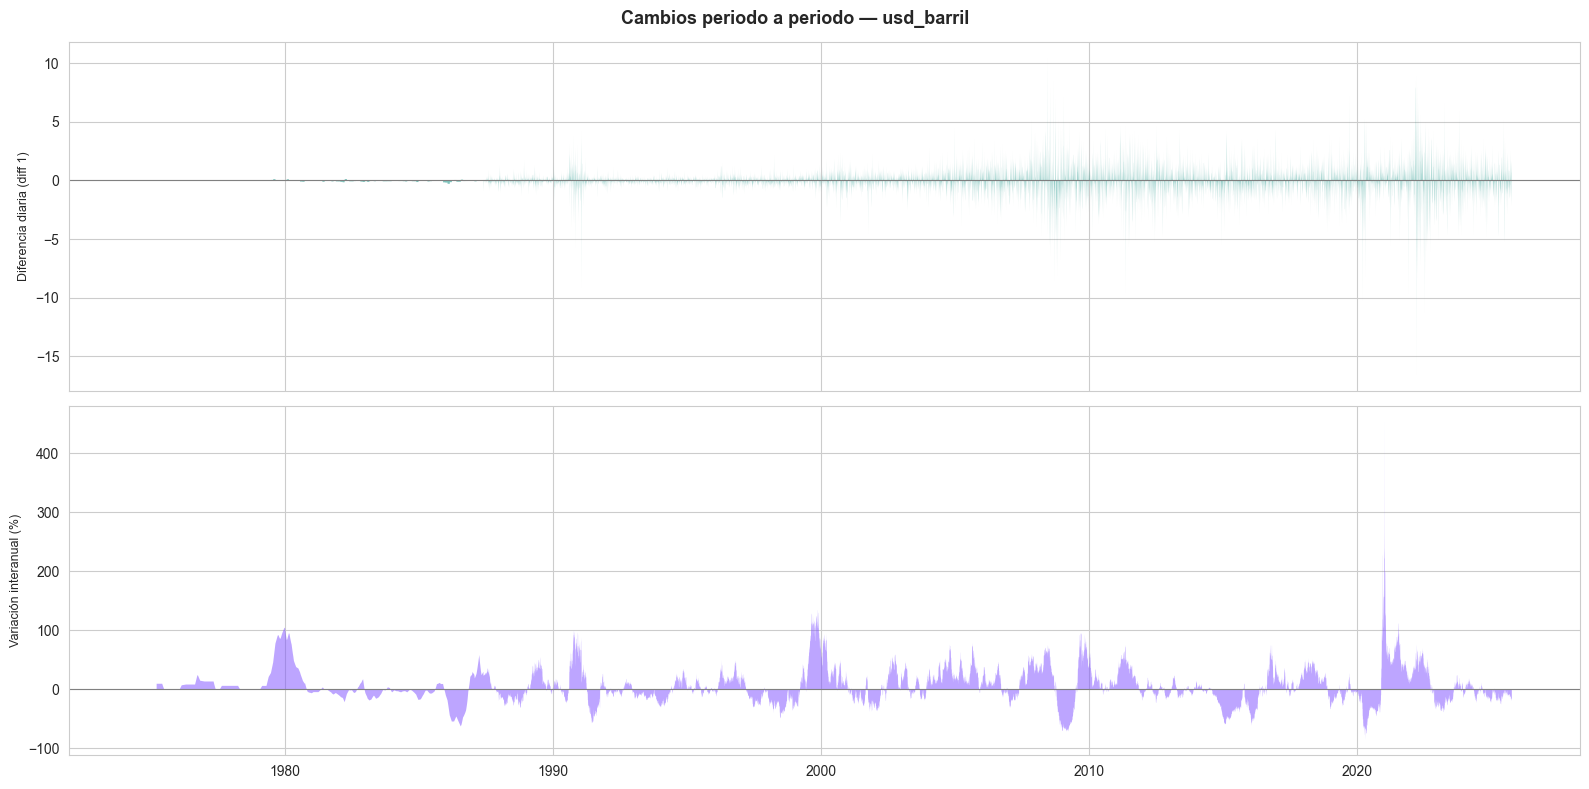

Estadísticas de la variación interanual (%):
count   18469.000
mean        6.780
std        30.460
min       -84.770
25%        -9.650
50%         1.610
75%        19.510
max       453.070


In [43]:
diff1 = y.diff(1).dropna()
pct_yoy = y.pct_change(252).dropna() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Cambios periodo a periodo — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].fill_between(diff1.index, diff1, 0, color='#00897B', alpha=0.5, lw=0)
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_ylabel('Diferencia diaria (diff 1)', fontsize=9)

axes[1].fill_between(pct_yoy.index, pct_yoy, 0, color='#7C4DFF', alpha=0.5, lw=0)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_ylabel('Variación interanual (%)', fontsize=9)

plt.tight_layout()
plt.show()

print('Estadísticas de la variación interanual (%):')
print(pct_yoy.describe().round(2).to_string())

### Análisis:

La diferencia diaria del `usd_barril` (panel superior) tiene aspecto de ruido con amplitud creciente en los episodios de estrés: prácticamente plana en los años 90, se ensancha de forma extrema en 2008-2009, 2014-2016 y, sobre todo, en 2020, cuando el desplome y el rebote del confinamiento producen los cambios diarios más violentos de toda la muestra. Esta heterocedasticidad confirma el clustering de volatilidad documentado en el residuo de la descomposición.

La variación interanual (panel inferior) ofrece la perspectiva relevante para la modelización y refleja la enorme amplitud cíclica del precio del crudo: media de 6,78%, mediana de 1,61% y una desviación típica de 30,46%, con un rango que va desde -84,77% (el desplome interanual de 1986 y el de 2020) hasta +453,07% (el repunte interanual desde el mínimo de 1998, amplificado por partir de una base muy baja). La distancia entre la media positiva y la mediana próxima a cero refleja que las grandes subidas interanuales, aunque infrecuentes, tienen un peso desproporcionado. Esta variación interanual porcentual es la transformación adoptada para el cruce con el paro: estacionaria, económicamente interpretable como shock del precio del crudo, y homocedástica frente a la diferencia absoluta, cuya varianza escalaría con el nivel del precio.

---
## 6. Estacionariedad y Autocorrelación

In [44]:
diff_est = y.diff(PERIODO_ESTACIONAL).dropna()
pct_est = ((y / y.shift(PERIODO_ESTACIONAL) - 1) * 100).dropna()  # variación interanual %

def test_estacionariedad(serie, nombre_serie, regression='c'):
    s = serie.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags='auto')
    estacionaria = (adf_p < 0.05) and (kpss_p >= 0.05)
    return {
        'serie': nombre_serie,
        'regression': regression,
        'ADF_stat': round(adf_stat, 4),
        'ADF_p': round(adf_p, 4),
        'ADF_H0_rechaza': adf_p < 0.05,
        'KPSS_stat': round(kpss_stat, 4),
        'KPSS_p': round(kpss_p, 4),
        'KPSS_H0_rechaza': kpss_p < 0.05,
        'conclusion': 'ESTACIONARIA' if estacionaria else 'NO ESTACIONARIA',
    }

series_test = [
    (y, f'{VAR_PRINCIPAL} (nivel)', 'c'),
    (diff1, f'{VAR_PRINCIPAL} (diff 1)', 'c'),
    (diff_est, f'{VAR_PRINCIPAL} (diff {PERIODO_ESTACIONAL})', 'c'),
    (pct_est, f'{VAR_PRINCIPAL} (var interanual %)', 'c'),
]

resultados_est = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test])

print('Tests de estacionariedad:')
print('=' * 85)
print(resultados_est.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_est.iterrows():
    h0_adf = 'rechaza H\u2080' if row['ADF_H0_rechaza'] else 'NO rechaza H\u2080'
    h0_kpss = 'rechaza H\u2080' if row['KPSS_H0_rechaza'] else 'NO rechaza H\u2080'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  (H\u2080 = ra\u00edz unitaria):  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS (H\u2080 = estacionaria):   stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    \u2192 {row['conclusion']}")
    print()

Tests de estacionariedad:
                        serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
           usd_barril (nivel)          c    -2.449  0.128           False     14.154   0.010             True NO ESTACIONARIA
          usd_barril (diff 1)          c   -18.072  0.000            True      0.035   0.100            False    ESTACIONARIA
        usd_barril (diff 365)          c    -6.028  0.000            True      0.140   0.100            False    ESTACIONARIA
usd_barril (var interanual %)          c    -6.764  0.000            True      0.173   0.100            False    ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  usd_barril (nivel)  (KPSS regression='c')
    ADF  (H₀ = raíz unitaria):  stat=-2.449, p=0.1283 (NO rechaza H₀)
    KPSS (H₀ = estacionaria):   stat=14.154, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  usd_barril (diff 1)  (KPSS regression='c')
    ADF  (H₀ = raíz unitaria)

### Análisis:

En niveles, ambos tests convergen en un diagnóstico claro de no estacionariedad: el ADF no rechaza la raíz unitaria (stat=-2,449, p=0,1283) y el KPSS la rechaza con un estadístico muy elevado (stat=14,154, p=0,0100), reflejo de los persistentes regímenes de precio bajo y alto que generan una no estacionariedad estructural en la serie.

La primera diferencia diaria produce el diagnóstico más limpio de toda la batería: el ADF rechaza la raíz unitaria de forma extrema (stat=-18,072, p=0,0000) y el KPSS no rechaza la estacionariedad (stat=0,035, p=0,1000), el patrón de ruido blanco propio del cambio de precio de un activo cotizado en mercados eficientes. La diferencia interanual (diff 365) y la variación interanual porcentual son igualmente estacionarias (ADF stat=-6,028 y -6,764 respectivamente, ambos con p=0,0000, y KPSS de 0,140 y 0,173 que no rechazan la estacionariedad), a diferencia de lo que ocurría con el tipo de cambio, donde las transformaciones interanuales no estacionarizaban a frecuencia diaria. La caracterización operativa a frecuencia trimestral, que es la del modelo, se valida en el bloque 6.1, donde se confirma que las tres formas diferenciadas son estacionarias y se justifica la elección de la variación interanual porcentual.

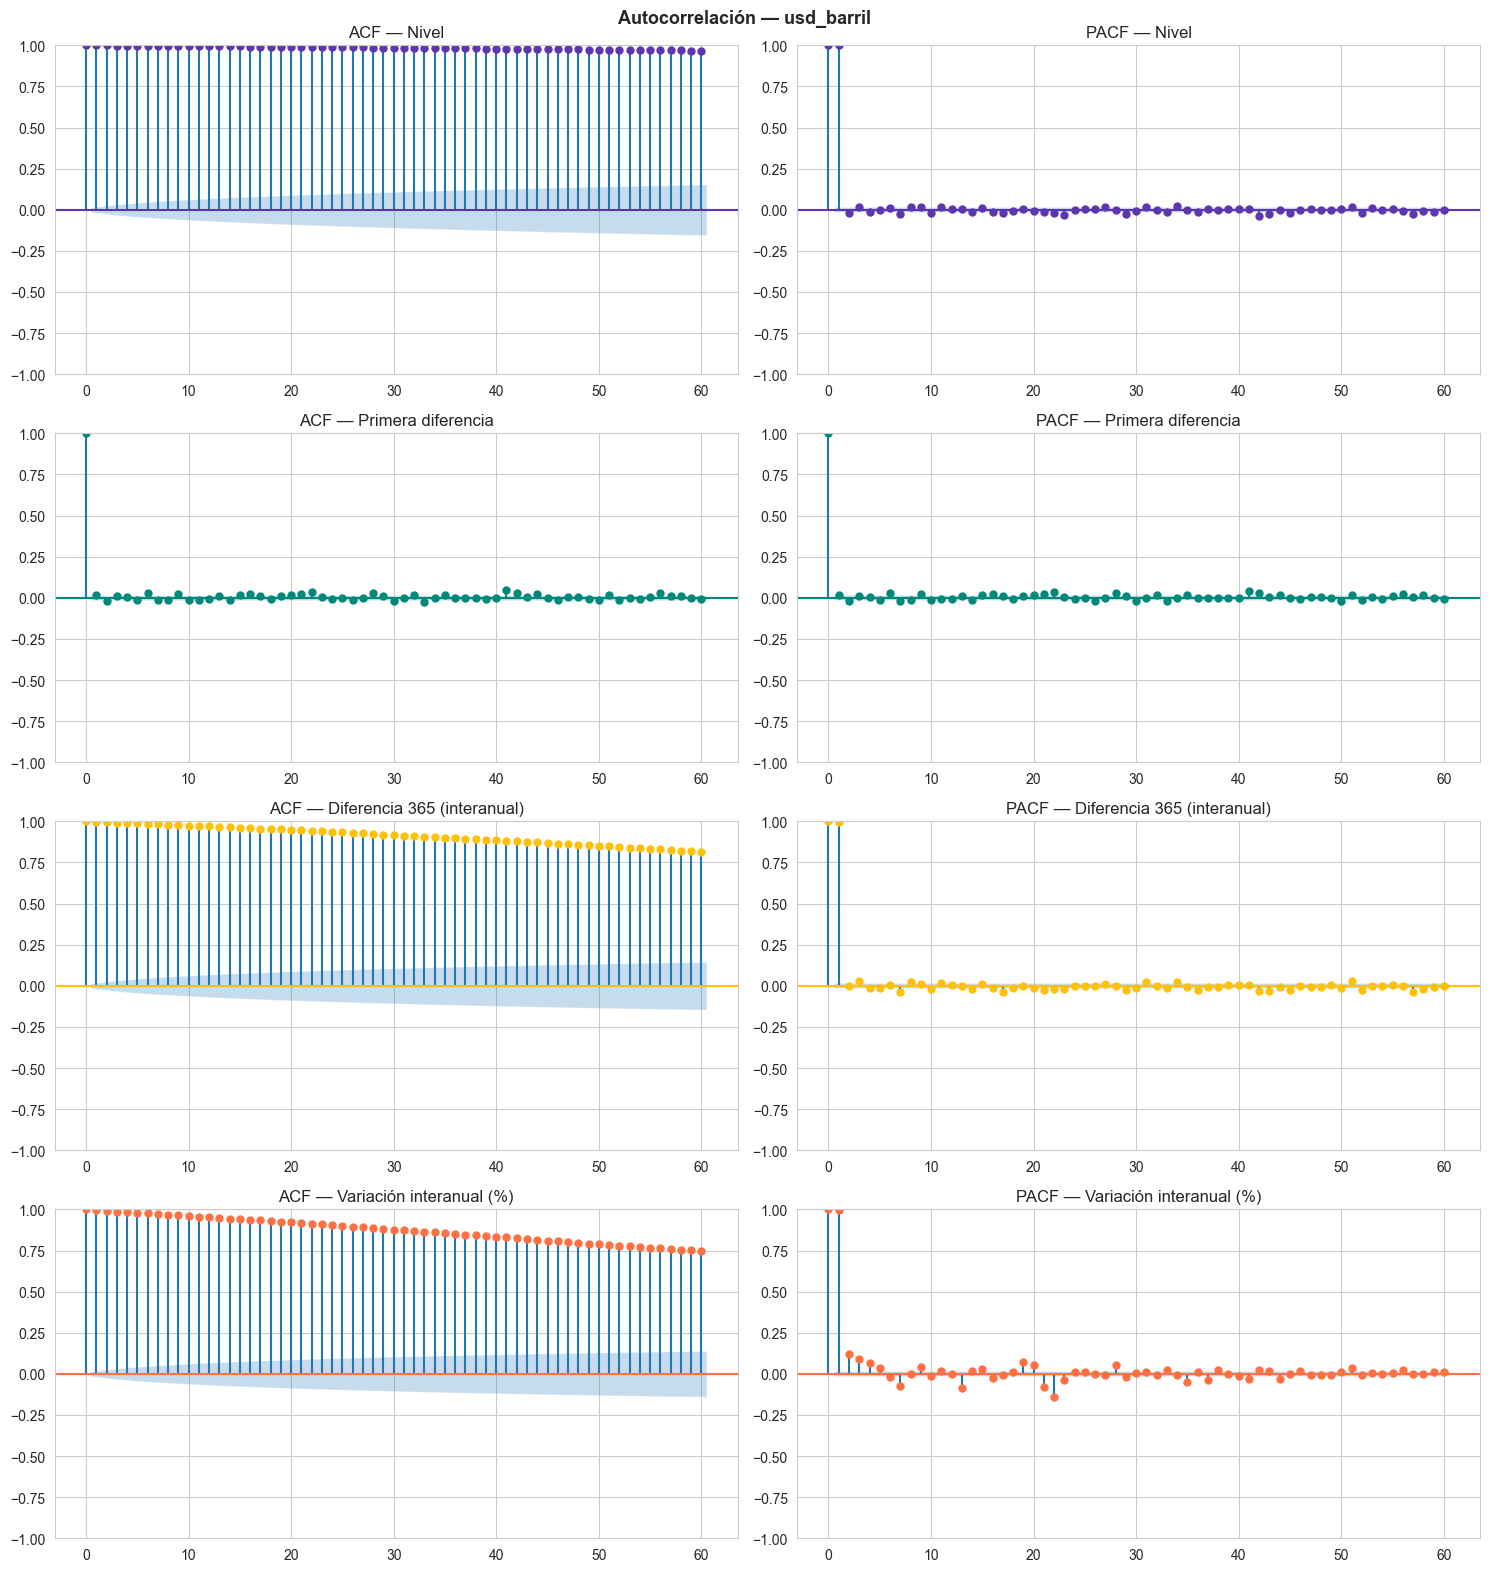

In [45]:
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
fig.suptitle(f'Autocorrelación — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel')
plot_pacf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel', method='ywm')
plot_acf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 0], color='#00897B',
         title='ACF — Primera diferencia')
plot_pacf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 1], color='#00897B',
          title='PACF — Primera diferencia', method='ywm')
plot_acf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 0], color='#FFC107',
         title=f'ACF — Diferencia {PERIODO_ESTACIONAL} (interanual)')
plot_pacf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 1], color='#FFC107',
          title=f'PACF — Diferencia {PERIODO_ESTACIONAL} (interanual)', method='ywm')
plot_acf(pct_est.dropna(), lags=LAGS_ACF, ax=axes[3, 0], color='#FF7043',
         title='ACF — Variación interanual (%)')
plot_pacf(pct_est.dropna(), lags=LAGS_ACF, ax=axes[3, 1], color='#FF7043',
          title='PACF — Variación interanual (%)', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

En niveles, el correlograma presenta el patrón canónico de serie no estacionaria: la ACF decae de forma lenta manteniéndose próxima a 1 a lo largo de todo el espectro y la PACF concentra la señal en un único pico dominante en el lag 1, la firma de un proceso autorregresivo con raíz cercana a la unidad, coherente con los regímenes persistentes de precio documentados.

Tras la primera diferencia diaria, tanto la ACF como la PACF caen a valores prácticamente nulos en todos los lags, configurando el patrón de ruido blanco propio del cambio de precio de un activo cotizado en mercados líquidos, en línea con el `HEUR_USD` y coherente con la hipótesis de eficiencia débil de los mercados de materias primas. La ausencia de estructura autorregresiva en la diferencia diaria confirma el diagnóstico de no estacionariedad en niveles; a frecuencia trimestral, la capacidad predictiva del petróleo provendrá de su cruce con la tasa de paro, no de la dinámica propia de la serie.

### 6.1 Validación a frecuencia trimestral

El bloque previo de tests caracteriza la serie a su frecuencia original, donde la información es más rica. La modelización del paro, sin embargo, opera a frecuencia trimestral (target EPA), por lo que las transformaciones operativas deben validarse a esa misma frecuencia.

Este bloque verifica que las conclusiones sobre estacionariedad se trasladan correctamente a la serie resampleada (por media trimestral, coherente con la naturaleza de la variable), sobre la que opera el modelo. Se evalúan las mismas cuatro transformaciones que a frecuencia original:
- nivel trimestral
- `Δ1` trimestral (cambio intertrimestral)
- `Δ4` trimestral (cambio interanual)
- variación interanual porcentual trimestral

In [46]:
# Resampleo a frecuencia trimestral
LAGS_ACF_Q = 16
METODO_Q = 'media'
y_q = df[VAR_PRINCIPAL].resample('QS').mean().dropna()

diff1_q = y_q.diff(1).dropna()
diff4_q = y_q.diff(4).dropna()
pct_q = ((y_q / y_q.shift(4) - 1) * 100).dropna()

series_test_q = [
    (y_q, f'{VAR_PRINCIPAL} trimestral (nivel)', 'ct'),
    (diff1_q, f'{VAR_PRINCIPAL} trimestral (Δ1)', 'c'),
    (diff4_q, f'{VAR_PRINCIPAL} trimestral (Δ4)', 'c'),
    (pct_q, f'{VAR_PRINCIPAL} trimestral (var interanual %)', 'c'),
]

resultados_q = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test_q])

print(f'Tests de estacionariedad — frecuencia TRIMESTRAL (resampleo: {METODO_Q}):')
print('=' * 85)
print(resultados_q.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_q.iterrows():
    h0_adf = 'rechaza H₀' if row['ADF_H0_rechaza'] else 'NO rechaza H₀'
    h0_kpss = 'rechaza H₀' if row['KPSS_H0_rechaza'] else 'NO rechaza H₀'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    → {row['conclusion']}")
    print()

Tests de estacionariedad — frecuencia TRIMESTRAL (resampleo: media):
                                   serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
           usd_barril trimestral (nivel)         ct    -1.941  0.313           False      0.172   0.028             True NO ESTACIONARIA
              usd_barril trimestral (Δ1)          c   -10.906  0.000            True      0.040   0.100            False    ESTACIONARIA
              usd_barril trimestral (Δ4)          c    -3.758  0.003            True      0.046   0.100            False    ESTACIONARIA
usd_barril trimestral (var interanual %)          c    -4.301  0.000            True      0.057   0.100            False    ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  usd_barril trimestral (nivel)  (KPSS regression='ct')
    ADF  stat=-1.941, p=0.3129 (NO rechaza H₀)
    KPSS stat=0.172, p=0.0284 (rechaza H₀)
    → NO ESTACIONARIA

  usd_barri

### Análisis:

La validación a frecuencia trimestral confirma y precisa el diagnóstico de la frecuencia diaria. El nivel sigue siendo no estacionario (ADF stat=-1,941, p=0,3129; KPSS stat=0,172, p=0,0284). Las tres formas diferenciadas resultan estacionarias: la primera diferencia `Δ1` con holgura extrema (ADF stat=-10,906, p=0,0000; KPSS stat=0,040, p=0,1000), la diferencia interanual `Δ4` (ADF stat=-3,758, p=0,0034; KPSS stat=0,046) y la variación interanual porcentual (ADF stat=-4,301, p=0,0004; KPSS stat=0,057). Las propiedades del proceso no cambian al resamplear; el resampleo por media reduce la varianza residual y deja los estadísticos muy limpios.

La elección de la forma no la deciden solo los p-valores. La `Δ1` es la más limpia estadísticamente, pero al ser una diferencia absoluta en dólares su varianza escala con el nivel del precio: un cambio de 10 dólares no es comparable a 20 dólares que a 140 dólares, lo que la hace fuertemente heterocedástica e inadecuada como input para selección de variables con Ridge y Lasso. Se adopta la variación interanual porcentual, que normaliza por el nivel, ofrece una escala homogénea y comparable con el resto del panel macro, y es el indicador económicamente canónico del shock del precio del crudo. A diferencia del tipo de interés, aquí la variación porcentual sí procede, porque el petróleo es un precio y no una tasa.

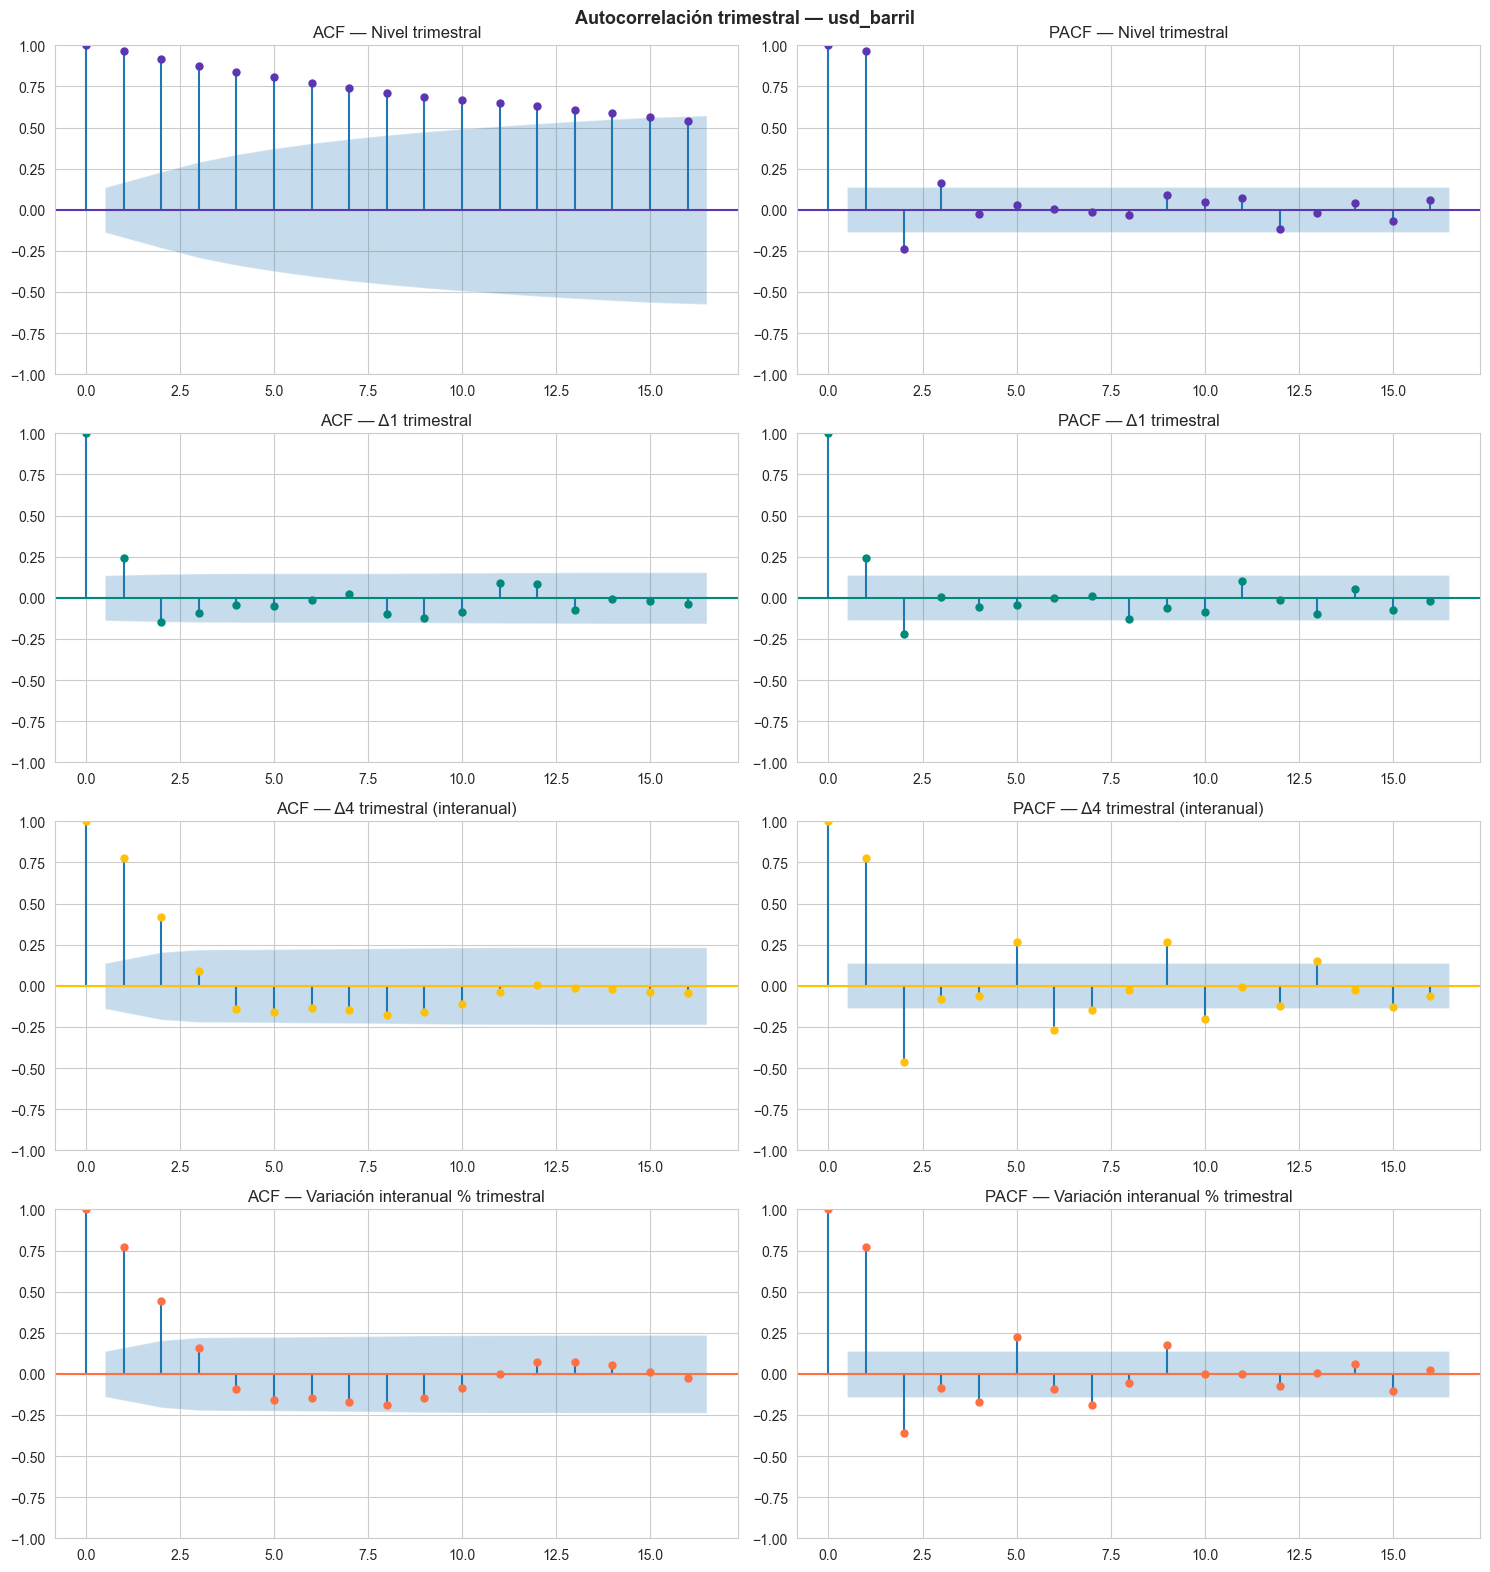

In [47]:
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
fig.suptitle(f'Autocorrelación trimestral — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y_q.dropna(), lags=LAGS_ACF_Q, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel trimestral')
plot_pacf(y_q.dropna(), lags=LAGS_ACF_Q, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel trimestral', method='ywm')
plot_acf(diff1_q, lags=LAGS_ACF_Q, ax=axes[1, 0], color='#00897B',
         title='ACF — Δ1 trimestral')
plot_pacf(diff1_q, lags=LAGS_ACF_Q, ax=axes[1, 1], color='#00897B',
          title='PACF — Δ1 trimestral', method='ywm')
plot_acf(diff4_q, lags=LAGS_ACF_Q, ax=axes[2, 0], color='#FFC107',
         title='ACF — Δ4 trimestral (interanual)')
plot_pacf(diff4_q, lags=LAGS_ACF_Q, ax=axes[2, 1], color='#FFC107',
          title='PACF — Δ4 trimestral (interanual)', method='ywm')
plot_acf(pct_q, lags=LAGS_ACF_Q, ax=axes[3, 0], color='#FF7043',
         title='ACF — Variación interanual % trimestral')
plot_pacf(pct_q, lags=LAGS_ACF_Q, ax=axes[3, 1], color='#FF7043',
          title='PACF — Variación interanual % trimestral', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

La estructura de autocorrelación a frecuencia trimestral confirma el diagnóstico de los tests. En nivel, la ACF decae lentamente desde valores próximos a 1, en torno a 0,55 todavía en el lag 16, y la PACF concentra la señal en un pico dominante en el lag 1 cercano a la unidad, el patrón de un AR(1) con raíz próxima a 1 propio de una serie no estacionaria.

La primera diferencia `Δ1` es la transformación más próxima al ruido blanco: la ACF muestra un único pico modesto en el lag 1 (aproximadamente 0,25) y entra en banda a partir del lag 2, coherente con el comportamiento de cambio de precio de un activo. La diferencia interanual `Δ4` y la variación interanual porcentual presentan, en cambio, una persistencia notable: ambas parten de un lag 1 elevado (aproximadamente 0,78) y decaen de forma gradual con varios lags significativos, y sus PACF muestran un pico fuerte en el lag 1 seguido de un valor negativo en el lag 2 (en torno a -0,4), estructura característica del solapamiento que introduce el filtro interanual. Las tres son estacionarias según los tests; la `Δ1` es la más limpia, pero la variación interanual porcentual se adopta por su homocedasticidad y su interpretación económica, asumiendo la mayor persistencia que el correlograma documenta.

In [48]:
# Estacionalidad trimestral reconstruida desde y_q
if len(y_q) >= 8:
    colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107']
    df_box_q = pd.DataFrame({
        'trimestre': y_q.index.quarter.map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}),
        'valor': y_q.values,
        'fecha': y_q.index.strftime('%Y-%m-%d'),
    })
    df_box_q['trimestre'] = pd.Categorical(df_box_q['trimestre'],
                                            categories=['Q1', 'Q2', 'Q3', 'Q4'], ordered=True)
    fig = px.box(
        df_box_q, x='trimestre', y='valor', color='trimestre',
        hover_data=['fecha'],
        title=f'Estacionalidad trimestral — {VAR_PRINCIPAL}',
        labels={'valor': UNIDADES, 'trimestre': 'Trimestre'},
        color_discrete_sequence=colores_bp,
    )
    fig.update_layout(showlegend=False, height=420)
    fig.show()

    medias_q = y_q.groupby(y_q.index.quarter).mean()
    cv_trimestral = medias_q.std() / medias_q.mean() * 100 if medias_q.mean() != 0 else 0
    medias_dict = {k: round(float(v), 3) for k, v in medias_q.items()}
    print('Media por trimestre:', medias_dict)
    estac = '(estacionalidad apreciable)' if cv_trimestral > 5 else '(estacionalidad leve)'
    print(f'CV entre trimestres: {cv_trimestral:.2f}% {estac}')

Media por trimestre: {1: 42.957, 2: 44.747, 3: 44.835, 4: 43.282}
CV entre trimestres: 2.22% (estacionalidad leve)


### Análisis:

La estacionalidad trimestral del `usd_barril` es prácticamente nula. Las cuatro cajas son visualmente indistinguibles en mediana, rango intercuartílico y bigotes, y las medias por trimestre se separan muy poco (Q1 42,957, Q2 44,747, Q3 44,835, Q4 43,282), con un coeficiente de variación entre trimestres de apenas 2,22%, calificado como estacionalidad leve. Las pequeñas diferencias, con un máximo en T2-T3 que podría asociarse a la mayor demanda de combustible del periodo estival en el hemisferio norte, carecen de relevancia frente a la amplitud cíclica del precio. El resampleo trimestral por media no introduce ni elimina variación estacional, y la serie no requiere corrección estacional previa.

---
## 7. Variables Derivadas Intra-Dataset
Ratios y transformaciones calculadas a partir de las columnas de este dataset.

In [49]:
df_der = pd.DataFrame(index=df.index)

df_der['yoy_pct'] = df['usd_barril'].pct_change(252) * 100
df_der['volatilidad_30d'] = df['usd_barril'].pct_change().rolling(30).std() * np.sqrt(252) * 100

print(f'Variables derivadas creadas ({len(df_der.columns)}):')
display(df_der.describe().round(3))

Variables derivadas creadas (2):


,yoy_pct,volatilidad_30d
count,18469.000,18691.000
mean,6.784,21.165
std,30.464,19.095
min,-84.775,0.000
25%,-9.655,7.871
50%,1.613,21.146
75%,19.514,29.319
max,453.070,270.411


### Análisis:

Se han construido dos variables derivadas del `usd_barril`, orientadas a capturar dimensiones complementarias de la dinámica del precio del crudo.

`yoy_pct` (variación interanual porcentual) reproduce la transformación estacionaria adoptada para el cruce con el paro: media de 6,784%, mediana de 1,613% y una desviación típica de 30,464%, con un rango de -84,775% a +453,070% que recoge la enorme amplitud de los shocks petrolíferos. Su perfil estacionario y su interpretación directa como variación del precio del crudo la convierten en la transformación de referencia.

`volatilidad_30d` (desviación típica móvil de 30 días de la diferencia diaria) cuantifica el clustering de volatilidad del mercado: su media de 21,165 y su máximo de 270,411 reflejan el contraste entre los periodos tranquilos, con volatilidad de base de 5-15, y los episodios de estrés extremo, con el pico absoluto en el desplome del confinamiento de 2020. Esta variable añade una dimensión de incertidumbre que va más allá del nivel o la variación del precio y que, en periodos de alta volatilidad, puede deprimir la inversión y la actividad con independencia de la dirección del movimiento.

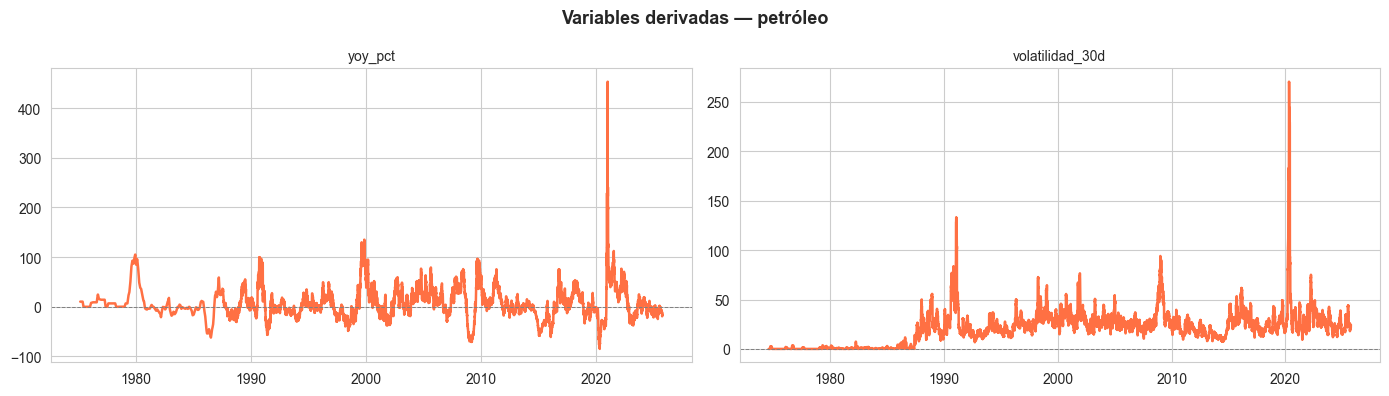

In [50]:
if not df_der.empty and len(df_der.columns) > 0:
    ncols = min(2, len(df_der.columns))
    nrows = (len(df_der.columns) + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(f'Variables derivadas — {NOMBRE}', fontsize=13, fontweight='bold')

    for ax, col in zip(axes, df_der.columns):
        serie = df_der[col].dropna()
        ax.plot(serie.index, serie, color='#FF7043', lw=1.8)
        ax.axhline(0, color='gray', lw=0.7, linestyle='--')
        ax.set_title(col, fontsize=10)

    for ax in axes[len(df_der.columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### Análisis:

La representación temporal de las dos variables derivadas confirma los estadísticos descriptivos y añade la dimensión temporal de cada una. `yoy_pct` describe las grandes oscilaciones interanuales del precio del crudo, con picos positivos en el segundo shock petrolífero de 1979-1980, en el repunte desde el mínimo de 1998 y en la recuperación post-confinamiento de 2021, y valles profundos en el contrashock de 1986, la crisis financiera de 2009, el colapso del shale de 2015 y el desplome de 2020. La amplitud de estas oscilaciones, sin tendencia y con reversión a una media próxima al 7%, confirma el carácter mean-reverting del crecimiento del precio.

`volatilidad_30d` permanece en una banda baja de 5-15 durante los periodos de mercado tranquilo y se dispara en cada episodio de estrés: los shocks de los años 80, la Guerra del Golfo, la crisis de 2008-2009, el colapso del shale de 2014-2016 y, de forma extrema, el confinamiento de 2020, cuando alcanza su máximo histórico. La estructura de picos aislados sobre una base estable confirma el clustering de volatilidad característico de los mercados de materias primas, de naturaleza condicional y no proporcional al nivel del precio.

In [51]:
# ── Guardar dataset enriquecido (trimestral) ───────────────────────────────────────
if not df_der.empty:
    # Eliminar columnas derivadas antiguas que ya no se calculan
    cols_antiguas = ['wti_yoy_pct', 'wti_volatilidad_30d', 'wti_brent_spread',
                     'wti_usd_barril', 'brent_usd_barril']
    df = df.drop(columns=[c for c in cols_antiguas if c in df.columns], errors='ignore')
    for col in df_der.columns:
        df[col] = df_der[col]

# Remuestrear a frecuencia trimestral
cols_num = [c for c in df.columns if df[c].dtype in ['float64', 'int64', 'float32']]
df_trimestral = df[cols_num].resample('QS').mean()
df_trimestral = df_trimestral.dropna(how='all')

# Guardar CSV trimestral
ruta_q = ruta.parent / (ruta.stem + '_trimestral.csv')
df_trimestral.to_csv(ruta_q)
print(f'CSV trimestral guardado: {ruta_q.name}')
print(f'  Columnas: {len(df_trimestral.columns)}')
print(f'  Rango: {df_trimestral.index.min().date()} — {df_trimestral.index.max().date()}')
print(f'  Observaciones: {len(df_trimestral)} trimestres')


CSV trimestral guardado: petroleo_precio_diario_barril_1946_2026_trimestral.csv
  Columnas: 6
  Rango: 1974-07-01 — 2025-10-01
  Observaciones: 206 trimestres


---
## 8. Tabla Resumen

In [52]:
est_q_nivel = resultados_q[resultados_q['serie'].str.contains('nivel')]['conclusion'].values[0]
est_q_d1 = resultados_q[resultados_q['serie'].str.contains('Δ1')]['conclusion'].values[0]
est_q_d4 = resultados_q[resultados_q['serie'].str.contains('Δ4')]['conclusion'].values[0]
est_q_pct = resultados_q[resultados_q['serie'].str.contains('var interanual')]['conclusion'].values[0]

if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):
    idx_max = indice_estacional.idxmax()
    idx_min = indice_estacional.idxmin()
else:
    idx_max = 'N/A'
    idx_min = 'N/A'

q1q, q3q = y_q.quantile(0.25), y_q.quantile(0.75)
iqr_q = q3q - q1q
outliers_q = y_q[(y_q < q1q - 1.5 * iqr_q) | (y_q > q3q + 1.5 * iqr_q)]

resumen = pd.DataFrame([{
    'Dataset':               NOMBRE,
    'Variable':              VAR_PRINCIPAL,
    'Frecuencia':            f'trimestral (resampleo: {METODO_Q})',
    'N obs original':        f"{len(y.dropna())} ({DATASET_CONFIG['frecuencia_original']})",
    'Rango':                 f'{y_q.index.min().date()} — {y_q.index.max().date()}',
    'N obs':                 len(y_q.dropna()),
    'Media':                 y_q.mean().round(2),
    'Mediana':               y_q.median().round(2),
    'Std':                   y_q.std().round(2),
    'CV (%)':                (y_q.std() / y_q.mean() * 100).round(1),
    'Mín (fecha)':           f'{y_q.min():.1f} ({y_q.idxmin().date()})',
    'Máx (fecha)':           f'{y_q.max():.1f} ({y_q.idxmax().date()})',
    'Outliers IQR':          len(outliers_q),
    '% faltantes (original)': f'{df[VAR_PRINCIPAL].isnull().mean()*100:.1f}%',
    'Estacionaria (nivel)':            est_q_nivel,
    'Estacionaria (Δ1)':               est_q_d1,
    'Estacionaria (Δ4)':               est_q_d4,
    'Estacionaria (var interanual %)': est_q_pct,
    'Periodo más alto':      idx_max,
    'Periodo más bajo':      idx_min,
}]).T

resumen.columns = ['Valor']
print('=' * 60)
print('TABLA RESUMEN (frecuencia trimestral)')
print('=' * 60)
print(resumen.to_string())

TABLA RESUMEN (frecuencia trimestral)
                                                         Valor
Dataset                                               petróleo
Variable                                            usd_barril
Frecuencia                       trimestral (resampleo: media)
N obs original                                  18721 (diaria)
Rango                                  1974-07-01 — 2025-10-01
N obs                                                      206
Media                                                   43.960
Mediana                                                 30.800
Std                                                     30.960
CV (%)                                                  70.400
Mín (fecha)                                  10.2 (1974-07-01)
Máx (fecha)                                 121.7 (2008-04-01)
Outliers IQR                                                 0
% faltantes (original)                                    0.0%
Estacionaria (niv

### Análisis:

La tabla resumen del `usd_barril` recoge los estadísticos principales sobre 18.721 observaciones diarias entre julio de 1974 y octubre de 2025 (206 trimestres tras el resampleo por media), sin valores faltantes. La media de 43,96 dólares supera notablemente a la mediana de 30,80, reflejo de la asimetría positiva de la distribución: el largo periodo de precios bajos ancla la mediana mientras la cola de precios altos de 2008-2014 y 2022 eleva la media. El coeficiente de variación de 70,4% es el más alto de todas las variables del proyecto y cuantifica la enorme amplitud del recorrido del precio, desde 10,2 dólares en el inicio de la muestra hasta 121,7 dólares de media trimestral en 2008.

El diagnóstico de estacionariedad fija la forma de la variable. El nivel no es estacionario (regímenes de precio persistentes). Las tres formas diferenciadas (`Δ1`, `Δ4` y variación interanual porcentual) son estacionarias a frecuencia trimestral; entre ellas se adopta la variación interanual porcentual, el crecimiento del precio del crudo, como forma de referencia para el cruce con el paro y para el panel de features. La razón es que, al ser el petróleo un precio con un rango enorme (de 10 a 144 dólares), la diferencia absoluta es fuertemente heterocedástica (su varianza escala con el nivel), mientras la variación porcentual normaliza por el nivel, ofrece una escala homogénea y comparable, idónea para Ridge y Lasso, y es el indicador canónico del shock petrolífero. A diferencia del tipo de interés, que es una tasa, aquí la variación porcentual sí tiene sentido económico por tratarse de un precio. El nivel queda disponible para los modelos que operan sobre series no estacionarias. La heterocedasticidad con clustering de volatilidad de la serie queda documentada como rasgo, sin tratamiento por logaritmo, que no procede en un precio sin crecimiento exponencial.

---
## 9. Análisis Cruzado con Desempleo
Relación entre **Petroleo** y el desempleo (EPA, desde 1976Q3).

In [53]:
ruta_parados_s9 = RUTA_BASE / 'parados_sexo_edad.csv'
df_par_s9 = pd.read_csv(ruta_parados_s9)
df_par_s9['fecha'] = pd.to_datetime(df_par_s9['fecha'])
df_par_s9 = df_par_s9.set_index('fecha').sort_index()
df_par_s9['tasa_paro_ambos_sexos_total'] = pd.to_numeric(
    df_par_s9['tasa_paro_ambos_sexos_total'], errors='coerce')

parados_aligned = df_par_s9['tasa_paro_ambos_sexos_total']
fecha_inicio_comun = max(parados_aligned.first_valid_index(), df.index.min())
parados_aligned = parados_aligned[parados_aligned.index >= fecha_inicio_comun]
df_resampled = df[[VAR_PRINCIPAL]].resample('QS').agg('mean').dropna()

# ── Qué variable cruzar con desempleo ──────────────────────────
main_s9 = (df_resampled[VAR_PRINCIPAL].pct_change(4) * 100).dropna()       # Variación interanual %
main_s9_label = f'Var. interanual % {VAR_PRINCIPAL}'             #
main_s9 = main_s9[main_s9.index >= fecha_inicio_comun].dropna()

print(f'Variable de cruce: {main_s9_label}')
print(f'Periodo común: {fecha_inicio_comun.date()} en adelante')
print(f'Observaciones alineadas: {len(main_s9)}')

Variable de cruce: Var. interanual % usd_barril
Periodo común: 1976-07-01 en adelante
Observaciones alineadas: 198


### Análisis:

El cruce con la tasa de paro se realiza sobre la variación interanual porcentual del `usd_barril`, la forma estacionaria adoptada, sobre 198 observaciones trimestrales comunes desde 1976-Q3. Esta transformación expresa el shock del precio del crudo en términos comparables a lo largo de toda la muestra y elimina la dependencia del régimen de precio que invalidaba el cruce en niveles.

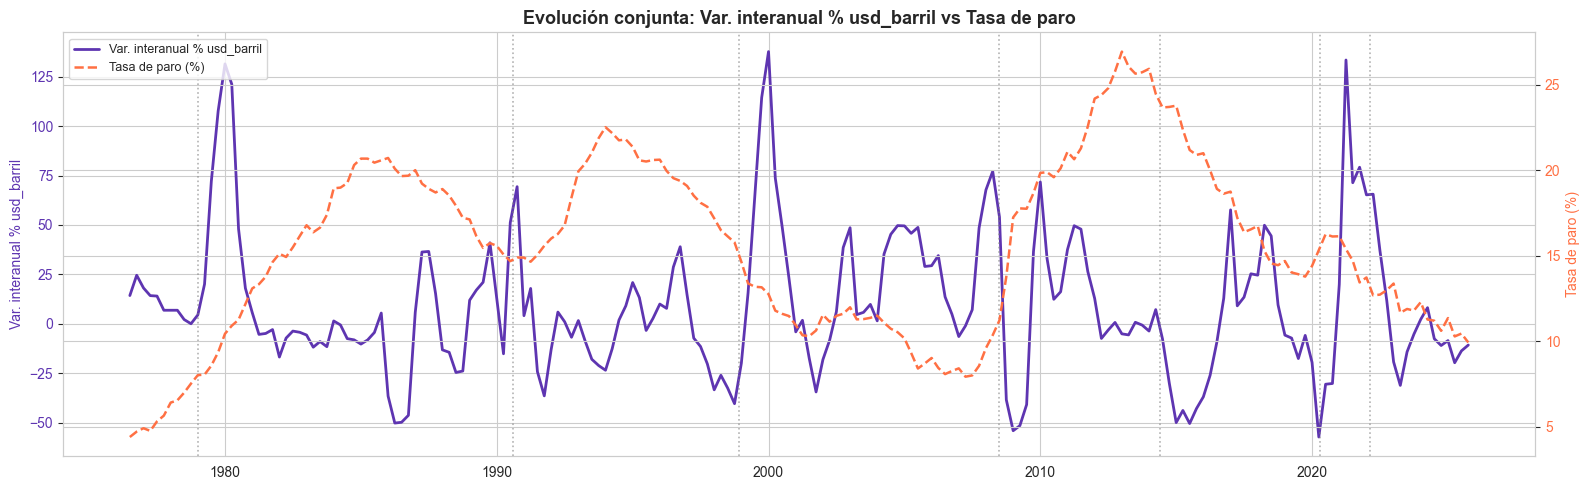

In [54]:
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.plot(main_s9.index, main_s9, color=COLOR_PRINCIPAL, lw=2,
         label=main_s9_label)
ax2.plot(parados_aligned.index, parados_aligned, color='#FF7043',
         lw=1.8, linestyle='--', label='Tasa de paro (%)')

ax1.set_ylabel(main_s9_label, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')

for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if main_s9.index.min() <= fecha_ev <= main_s9.index.max():
        ax1.axvline(fecha_ev, color='gray', linestyle=':', lw=1.2, alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_title(f'Evolución conjunta: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis:

La evolución conjunta de la variación interanual del `usd_barril` y la tasa de paro muestra una relación de signo predominantemente inverso, aunque modulada por la naturaleza de los shocks. La variación del precio del crudo oscila con gran amplitud (de aproximadamente -55% a +135%) alrededor de su media positiva, con los grandes picos alcistas en el segundo shock petrolífero de 1979-1980, el repunte de 2000 y la recuperación de 2021, y los valles en el contrashock de 1986, la crisis financiera de 2009 y el confinamiento de 2020.

El rasgo dominante es que el precio del crudo es procíclico: tiende a subir durante las expansiones globales de demanda, cuando el paro desciende, y a desplomarse en las recesiones, cuando el paro escala. Así, el ciclo alcista del crudo de 2002-2008 coincide con la caída del paro del 15% al 8%, y los desplomes de 2009 y 2020 acompañan repuntes del desempleo. El canal de demanda, en el que el precio del petróleo refleja el pulso de la actividad mundial, parece dominar sobre el canal de oferta, que predeciría el signo contrario (un encarecimiento del crudo deprimiría la actividad y elevaría el paro). El análisis cuantitativo siguiente confirma una correlación negativa moderada.

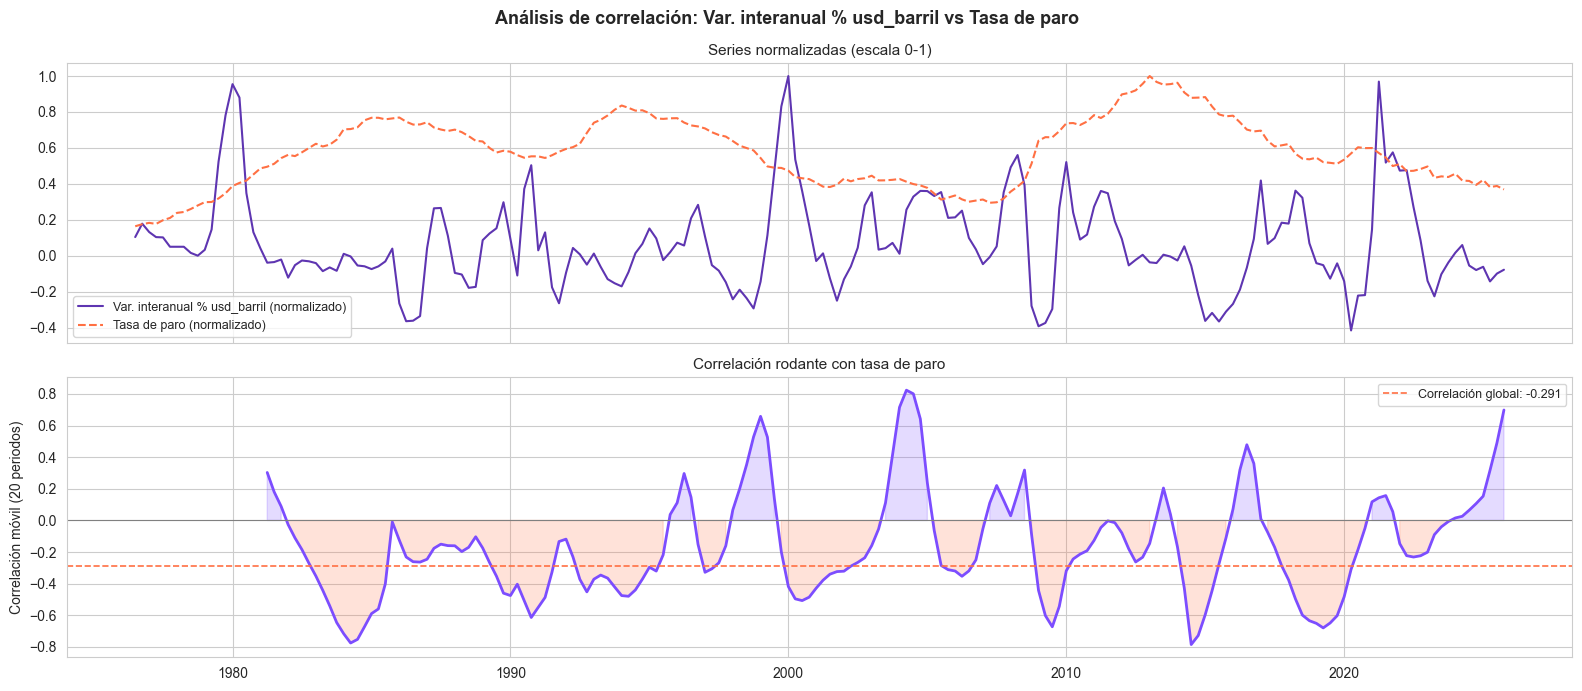

Correlación de Pearson global: -0.2913


In [55]:
ventana_corr = 20

df_cross = pd.DataFrame({'petroleo': main_s9, 'parados': parados_aligned}).dropna()
rolling_corr = df_cross['petroleo'].rolling(ventana_corr).corr(df_cross['parados'])
corr_global = df_cross['petroleo'].corr(df_cross['parados'])

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df_cross.index, df_cross['petroleo'] / df_cross['petroleo'].max(),
             color=COLOR_PRINCIPAL, lw=1.5, label=f'{main_s9_label} (normalizado)')
axes[0].plot(df_cross.index, df_cross['parados'] / df_cross['parados'].max(),
             color='#FF7043', lw=1.5, linestyle='--', label='Tasa de paro (normalizado)')
axes[0].legend(fontsize=9)
axes[0].set_title('Series normalizadas (escala 0-1)', fontsize=11)

axes[1].plot(rolling_corr.index, rolling_corr, color='#7C4DFF', lw=2)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axhline(corr_global, color='#FF7043', lw=1.2, linestyle='--',
                label=f'Correlación global: {corr_global:.3f}')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr > 0, alpha=0.2, color='#7C4DFF')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr < 0, alpha=0.2, color='#FF7043')
axes[1].set_ylabel(f'Correlación móvil ({ventana_corr} periodos)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_title('Correlación rodante con tasa de paro', fontsize=11)

fig.suptitle(f'Análisis de correlación: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Correlación de Pearson global: {corr_global:.4f}')

### Análisis:

La correlación global entre la variación interanual del `usd_barril` y la tasa de paro es de -0,2913, negativa y moderada, la más elevada en valor absoluto de todas las variables no poblacionales del EDA. El signo negativo es el del canal de demanda: el precio del petróleo crece cuando la economía mundial se expande y el paro baja, y se desploma en las recesiones cuando el paro sube. El canal de oferta, que predeciría una correlación positiva (encarecimiento del crudo seguido de más desempleo), queda dominado por el de demanda en el agregado de la muestra.

La correlación rodante a 20 trimestres es muy inestable, oscilando entre aproximadamente +0,8 y -0,8 con numerosos cruces de cero, lo que indica que el signo de la relación depende de la naturaleza de cada shock. Los tramos fuertemente negativos (1983-1988, 1992-1998, 2008-2016) corresponden a periodos en que el precio del crudo acompaña el ciclo de demanda, mientras los tramos positivos reflejan episodios en que un shock de oferta encarece el crudo a la vez que deteriora el empleo. La correlación global de -0,2913 es el promedio de esos regímenes con predominio del componente negativo.

Para la caracterización de la variable, el petróleo es uno de los regresores con mayor poder potencial sobre el paro, aunque su relación es condicional al tipo de shock dominante; su aprovechamiento se difiere a la fase de feature engineering.

In [56]:
df_cross['decada'] = (df_cross.index.year // 10 * 10).astype(str) + 's'
paleta_decadas = ['#1565C0', '#00897B', '#FF7043', '#7C4DFF', '#FFC107', '#AD1457']

df_scatter = df_cross.reset_index().rename(columns={'index': 'fecha', df_cross.index.name or 'index': 'fecha'})
if 'fecha' not in df_scatter.columns:
    df_scatter.insert(0, 'fecha', df_cross.index.strftime('%Y-%m-%d'))
else:
    df_scatter['fecha'] = pd.to_datetime(df_scatter['fecha']).dt.strftime('%Y-%m-%d')

fig = px.scatter(
    df_scatter, x='petroleo', y='parados',
    color='decada',
    hover_data=['fecha'],
    trendline='ols',
    trendline_scope='overall',
    color_discrete_sequence=paleta_decadas,
    title=f'Dispersión por década: {main_s9_label} vs Desempleo',
    labels={
        'petroleo': main_s9_label,
        'parados': 'Tasa de paro (%)',
        'decada': 'Década', 'fecha': 'Fecha',
    },
)
fig.for_each_trace(lambda t: t.update(name='Tendencia global') if t.name == 'Overall Trendline' else None)
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.update_layout(height=520)
fig.show()

### Análisis:

El diagrama de dispersión por década confirma la relación inversa entre la variación del precio del crudo y el paro. La recta de tendencia global tiene pendiente negativa visible, desde aproximadamente 18% de paro en el extremo de variación -50% hasta cerca del 10% en el extremo +130%, coherente con la correlación global de -0,29: los periodos de fuerte crecimiento del precio del petróleo se asocian a niveles de paro más bajos, la expresión del canal de demanda.

La nube es muy dispersa, lo que refleja que la relación, aunque presente, es ruidosa y modulada por otros factores. La estratificación por década no es tan limpia como en el PIB: los años 2000 (morados) tienden a situarse en la zona de paro bajo y los 2010 (amarillos) en la de paro alto, pero con considerable solapamiento horizontal, porque un mismo crecimiento del precio del crudo ha coexistido con regímenes de paro muy distintos según el contexto macroeconómico. La pendiente negativa es genuina pero débil, consistente con un petróleo que aporta señal sobre el ciclo pero condicionada al tipo de shock.

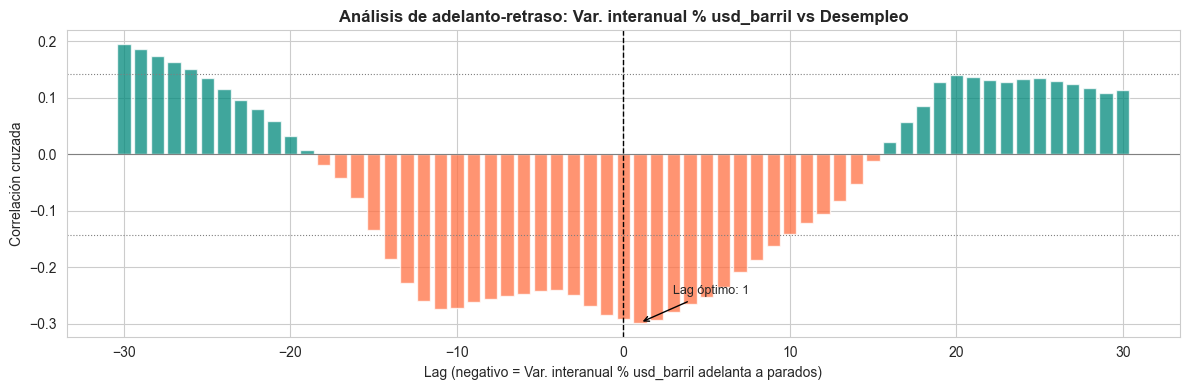

Lag con máxima correlación: 1 periodos
Correlación en ese lag: -0.2978
Banda de significancia (±2/√N): ±0.1421


In [57]:
max_lag = LAGS_ACF // 2

sa = (df_cross['petroleo'] - df_cross['petroleo'].mean()) / df_cross['petroleo'].std()
sb = (df_cross['parados'] - df_cross['parados'].mean()) / df_cross['parados'].std()

lags_range = range(-max_lag, max_lag + 1)
ccf_vals = [sa.corr(sb.shift(-lag)) for lag in lags_range]

fig, ax = plt.subplots(figsize=(12, 4))
colors_ccf = ['#00897B' if v > 0 else '#FF7043' for v in ccf_vals]
ax.bar(list(lags_range), ccf_vals, color=colors_ccf, alpha=0.75)
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='black', lw=1, linestyle='--')
sig = 2 / np.sqrt(len(df_cross))
ax.axhline(sig, color='gray', lw=0.8, linestyle=':')
ax.axhline(-sig, color='gray', lw=0.8, linestyle=':')

lag_max = list(lags_range)[np.argmax(np.abs(ccf_vals))]
ax.annotate(f'Lag óptimo: {lag_max}', xy=(lag_max, ccf_vals[lag_max + max_lag]),
            xytext=(lag_max + 2, ccf_vals[lag_max + max_lag] + 0.05),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel(f'Lag (negativo = {main_s9_label} adelanta a parados)', fontsize=10)
ax.set_ylabel('Correlación cruzada', fontsize=10)
ax.set_title(f'Análisis de adelanto-retraso: {main_s9_label} vs Desempleo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Lag con máxima correlación: {lag_max} periodos')
print(f'Correlación en ese lag: {ccf_vals[lag_max + max_lag]:.4f}')
print(f'Banda de significancia (±2/√N): ±{sig:.4f}')

### Análisis:

El análisis de adelanto-retraso muestra una correlación cruzada negativa, amplia y aproximadamente simétrica en torno al origen, con el lag óptimo en +1 trimestre y correlación de -0,2978, apenas distinguible de la correlación contemporánea. Toda la franja central, desde el lag -15 hasta el +15, se mantiene en terreno negativo y supera la banda de significancia de ±0,1421, lo que indica que la relación inversa entre la variación del precio del crudo y el paro no se concentra en un horizonte concreto sino que es esencialmente contemporánea y persiste a varios trimestres de distancia en ambos sentidos.

Esta simetría es coherente con el carácter procíclico del precio del petróleo: al moverse junto con el ciclo de demanda global, su correlación con el paro es de signo estable alrededor del momento contemporáneo, sin un mecanismo de transmisión adelantada nítido. Los extremos del espectro (más allá de ±20 trimestres) cambian a correlaciones positivas débiles, reflejo del desfase entre los largos ciclos del precio del crudo y los del desempleo. El lag óptimo de +1, prácticamente contemporáneo, no constituye un predictor operativo: la utilidad del petróleo reside en su co-movimiento con el ciclo, no en un adelanto temporal aprovechable, y su explotación se difiere a la fase de feature engineering.